# EDA: Universal Metadata (WLASL + kolejne datasety)

Notebook analizuje plik `merged_datasets/universal_metadata_has_video.csv` i tworzy wykresy/statystyki:
1. Ile wideo mamy lokalnie, a ile brakuje
2. Rozklad liczby klatek i dlugosci znaku
3. Rozklad FPS
4. Rozklad liczby probek na klase
5. Relacja signer -> znak
6. Rozmiary wideo (szerokosc/wysokosc)
7. Korelacje i dodatkowe statystyki

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, spearmanr

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [6]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
CSV_PATH = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_has_video_wlasl_msasl_merged.csv'

print('CSV_PATH:', CSV_PATH)
print('Exists:', CSV_PATH.exists())

df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
df.head()

CSV_PATH: D:\college\sem_mag_1\szum\merged_datasets\universal_metadata_has_video_wlasl_msasl_merged.csv
Exists: True
Shape: (12227, 12)


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
0,25,msasl,D:\college\sem_mag_1\szum\MS-ASL\videos_MS_ASL...,0,72.0,73.0,2.880,25.000,0,True,480.0,360.0
1,50,msasl,D:\college\sem_mag_1\szum\MS-ASL\videos_MS_ASL...,34,89.0,56.0,1.848,29.753,29,True,540.0,360.0
2,50,msasl,D:\college\sem_mag_1\szum\MS-ASL\videos_MS_ASL...,89,169.0,81.0,2.689,29.753,29,True,540.0,360.0
3,50,msasl,D:\college\sem_mag_1\szum\MS-ASL\videos_MS_ASL...,169,221.0,53.0,1.748,29.753,29,True,540.0,360.0
4,a,asldeafined,C:\Users\kacpe\source\repos\szum\kaggle_datase...,1,125.0,125.0,4.167,30.000,21,True,640.0,480.0


## 2) Histogram liczby klatek i dlugosci znaku

In [ ]:
length_stats = df['length_frames'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
duration_stats = df['duration_sec'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
frame_start_stats = df['start_frame'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print('Statystyki length_frames:')
display(length_stats.to_frame('length_frames'))
print('Statystyki duration_sec:')
display(duration_stats.to_frame('duration_sec'))
print('Statystyki frame_start:')
display(frame_start_stats.to_frame('start_frame'))


KeyError: 'frame_start'

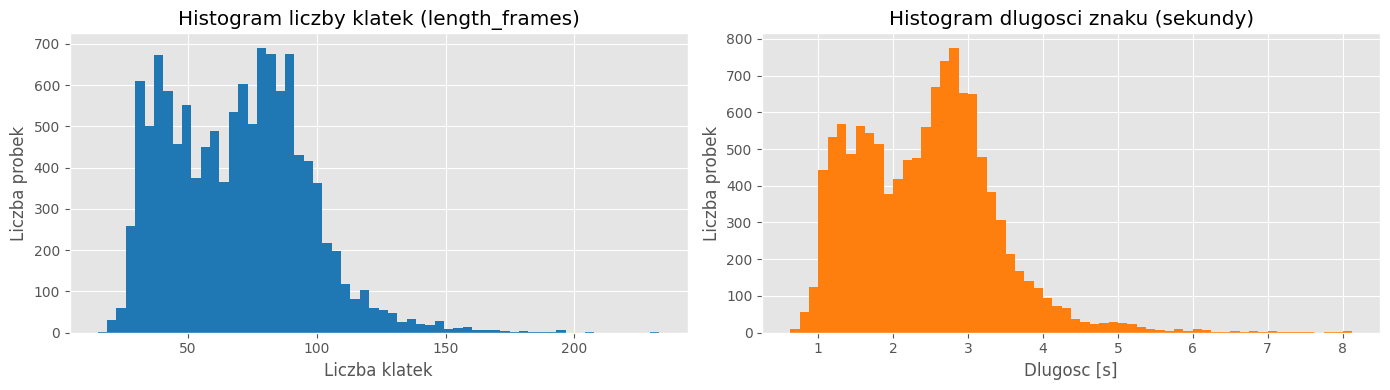

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['length_frames'].dropna().hist(bins=60, ax=axes[0], color='#1f77b4')
axes[0].set_title('Histogram liczby klatek (length_frames)')
axes[0].set_xlabel('Liczba klatek')
axes[0].set_ylabel('Liczba probek')

df['duration_sec'].dropna().hist(bins=60, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Histogram dlugosci znaku (sekundy)')
axes[1].set_xlabel('Dlugosc [s]')
axes[1].set_ylabel('Liczba probek')

plt.tight_layout()
plt.show()

## 3) Rozklad FPS

In [26]:
fps_stats = df['fps'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
display(fps_stats.to_frame('fps'))

fps_counts = df['fps'].round(3).value_counts().sort_index()
print('Najczestsze wartosci FPS:')
display(fps_counts.sort_values(ascending=False).head(15).to_frame('count'))

,fps
count,11980.000000
mean,28.530535
std,3.101907
min,12.000000
10%,23.976083
25%,25.000000
50%,29.970000
75%,30.000000
90%,30.307082
95%,30.340375


Najczestsze wartosci FPS:


,count
fps,
29.970,4753
23.976,2134
25.000,1126
30.000,710
30.003,261
29.997,259
29.996,234
30.004,226
24.000,161


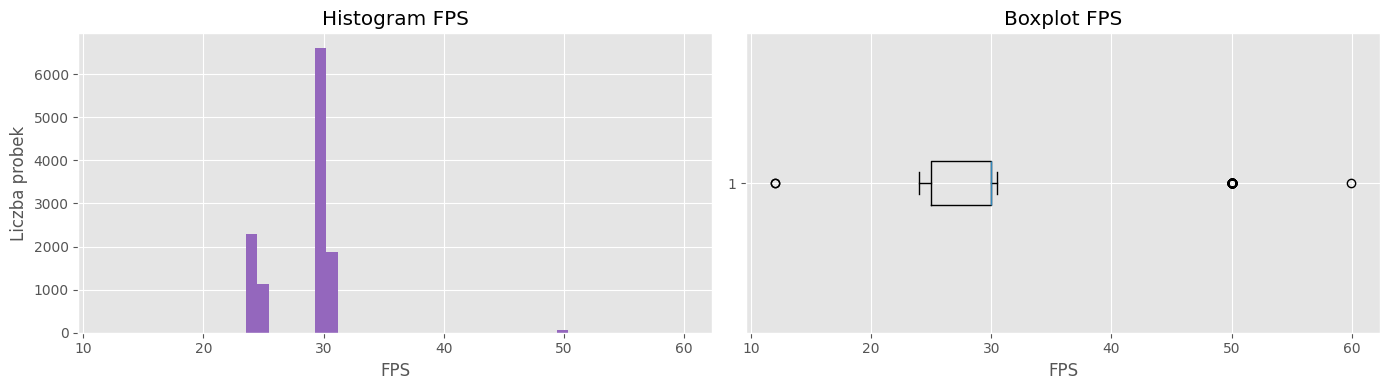

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['fps'].dropna().hist(bins=50, ax=axes[0], color='#9467bd')
axes[0].set_title('Histogram FPS')
axes[0].set_xlabel('FPS')
axes[0].set_ylabel('Liczba probek')

axes[1].boxplot(df['fps'].dropna(), vert=False)
axes[1].set_title('Boxplot FPS')
axes[1].set_xlabel('FPS')

plt.tight_layout()
plt.show()

## 4) Ile probek na klase (label)

In [28]:
label_counts = df['label'].value_counts()
print('Liczba klas:', df['label'].nunique())
print('Srednia liczba probek/klase:', round(label_counts.mean(), 2))
print('Mediana liczby probek/klase:', round(label_counts.median(), 2))
print('Min/Max probek na klase:', int(label_counts.min()), '/', int(label_counts.max()))

display(label_counts.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame('samples_per_label'))
display(label_counts.head(20).to_frame('count').rename_axis('label'))

Liczba klas: 2000
Srednia liczba probek/klase: 5.99
Mediana liczby probek/klase: 6.0
Min/Max probek na klase: 2 / 16


,samples_per_label
count,2000.000000
mean,5.990000
std,1.945454
min,2.000000
10%,4.000000
25%,5.000000
50%,6.000000
75%,7.000000
90%,9.000000
95%,10.000000


,count
label,
before,16
thin,16
cool,16
drink,15
go,15
computer,14
who,14
cousin,14
help,14


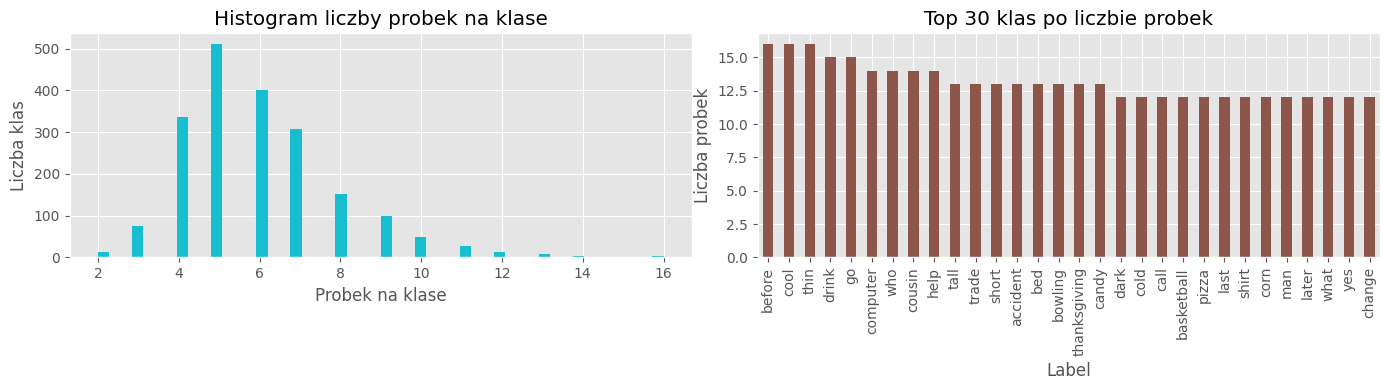

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

label_counts.hist(bins=50, ax=axes[0], color='#17becf')
axes[0].set_title('Histogram liczby probek na klase')
axes[0].set_xlabel('Probek na klase')
axes[0].set_ylabel('Liczba klas')

label_counts.sort_values(ascending=False).head(30).plot(kind='bar', ax=axes[1], color='#8c564b')
axes[1].set_title('Top 30 klas po liczbie probek')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Liczba probek')

plt.tight_layout()
plt.show()

## 5) Signer vs znak (korelacja i zaleznosci)

In [30]:
signer_counts = df['signer_id'].value_counts(dropna=False)
labels_per_signer = df.groupby('signer_id')['label'].nunique().sort_values(ascending=False)

print('Liczba signerow:', df['signer_id'].nunique())
print('Srednia liczba probek na signera:', round(signer_counts.mean(), 2))
print('Srednia liczba unikalnych labeli na signera:', round(labels_per_signer.mean(), 2))

display(signer_counts.head(20).to_frame('samples').rename_axis('signer_id'))
display(labels_per_signer.head(20).to_frame('unique_labels').rename_axis('signer_id'))

Liczba signerow: 78
Srednia liczba probek na signera: 153.59
Srednia liczba unikalnych labeli na signera: 138.4


,samples
signer_id,
11,1983
12,1380
13,966
4,723
10,685
2,561
41,495
21,439
38,429


,unique_labels
signer_id,
11,1506
12,1327
13,946
2,558
4,544
10,497
41,483
21,434
38,420


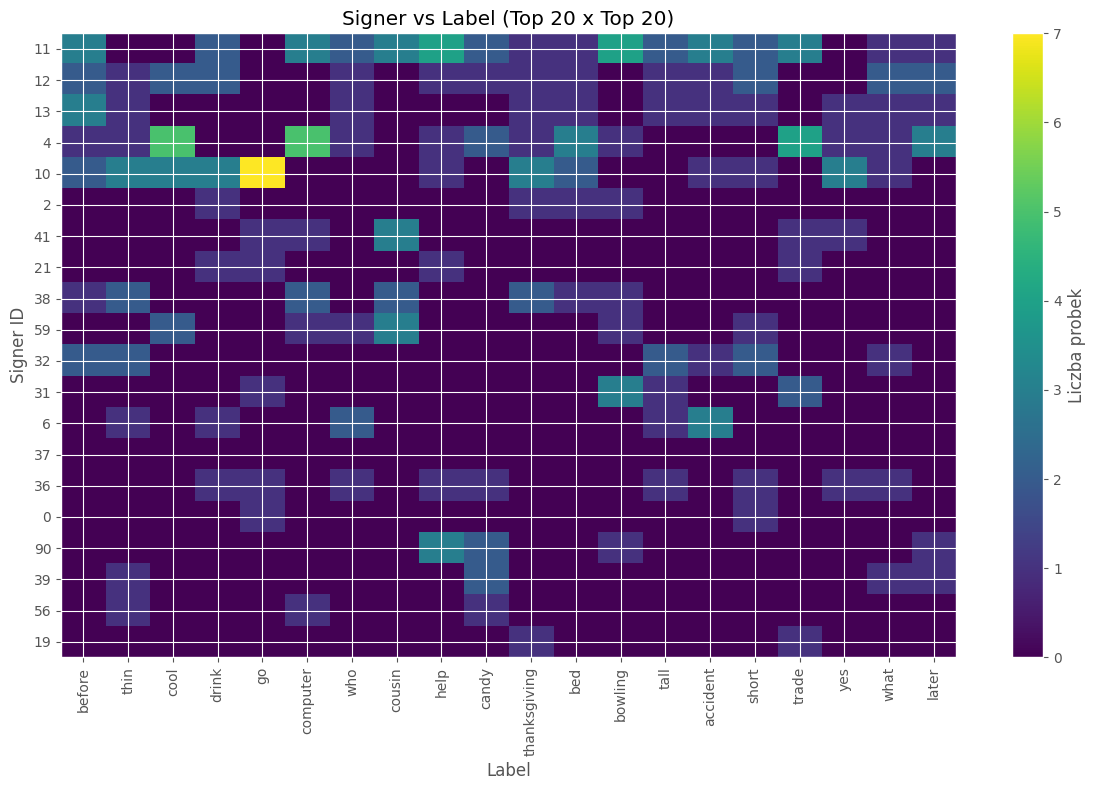

In [31]:
top_signers = signer_counts.head(20).index
top_labels = label_counts.head(20).index

heat = pd.crosstab(df['signer_id'], df['label']).reindex(index=top_signers, columns=top_labels, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heat.values, aspect='auto')
ax.set_title('Signer vs Label (Top 20 x Top 20)')
ax.set_xlabel('Label')
ax.set_ylabel('Signer ID')
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=90)
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
fig.colorbar(im, ax=ax, label='Liczba probek')
plt.tight_layout()
plt.show()

In [32]:
# Cramer's V dla zaleznosci dwoch zmiennych kategorycznych: signer_id i label
contingency = pd.crosstab(df['signer_id'], df['label'])
chi2, p_value, dof, _ = chi2_contingency(contingency)
n = contingency.values.sum()
r, k = contingency.shape
cramers_v = np.sqrt((chi2 / n) / max(min(r - 1, k - 1), 1))

print(f'Chi2: {chi2:.2f}')
print(f'p-value: {p_value:.6e}')
print(f"Cramer's V: {cramers_v:.4f}")

if cramers_v < 0.1:
    print('Interpretacja: bardzo slaba zaleznosc')
elif cramers_v < 0.3:
    print('Interpretacja: slaba/umiarkowana zaleznosc')
elif cramers_v < 0.5:
    print('Interpretacja: umiarkowana/silna zaleznosc')
else:
    print('Interpretacja: silna zaleznosc')

Chi2: 151041.00
p-value: 9.999999e-01
Cramer's V: 0.4046
Interpretacja: umiarkowana/silna zaleznosc


## 6) Histogram rozmiarow wideo

In [33]:
size_df = df[['video_width', 'video_height']].dropna()
print('Liczba probek z dostepnym rozmiarem:', len(size_df))
display(size_df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

top_res = df.dropna(subset=['video_width', 'video_height']).assign(res=lambda x: x['video_width'].astype(int).astype(str) + 'x' + x['video_height'].astype(int).astype(str))['res'].value_counts().head(15)
print('Najczestsze rozdzielczosci:')
display(top_res.to_frame('count'))

Liczba probek z dostepnym rozmiarem: 11980


,video_width,video_height
count,11980.000000,11980.000000
mean,759.697830,459.762604
std,544.235755,292.665907
min,288.000000,180.000000
10%,288.000000,192.000000
25%,320.000000,240.000000
50%,640.000000,400.000000
75%,720.000000,480.000000
90%,1920.000000,1080.000000
95%,1920.000000,1080.000000


Najczestsze rozdzielczosci:


,count
res,
288x192,2668
720x400,1875
640x480,1824
1920x1080,1768
320x240,1584
656x370,1045
1280x720,721
736x414,195
320x180,161


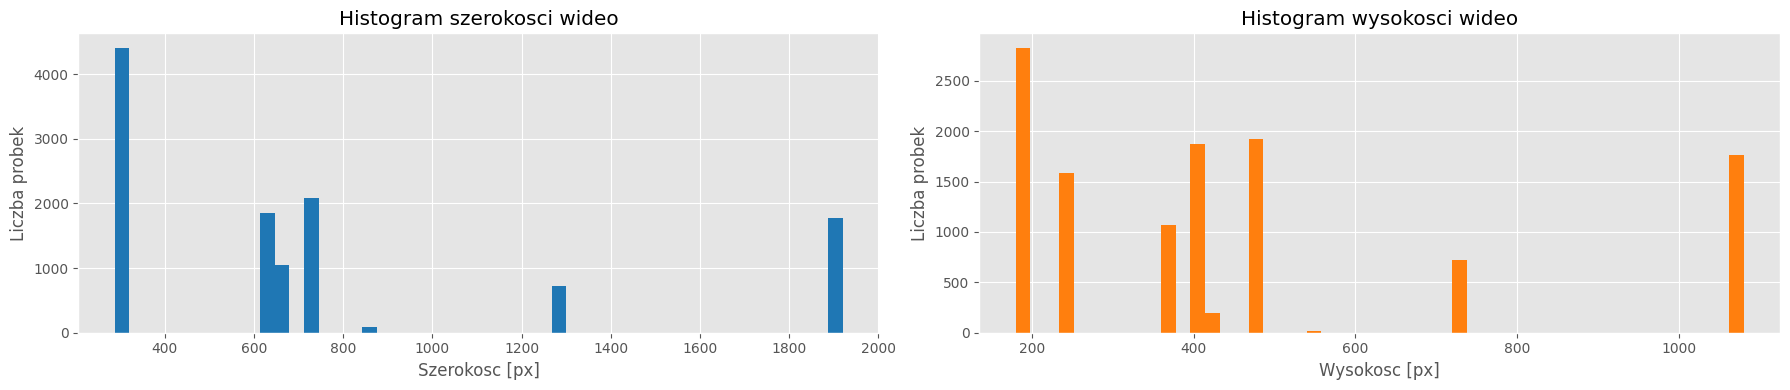

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

df['video_width'].dropna().hist(bins=50, ax=axes[0], color='#1f77b4')
axes[0].set_title('Histogram szerokosci wideo')
axes[0].set_xlabel('Szerokosc [px]')
axes[0].set_ylabel('Liczba probek')

df['video_height'].dropna().hist(bins=50, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Histogram wysokosci wideo')
axes[1].set_xlabel('Wysokosc [px]')
axes[1].set_ylabel('Liczba probek')

plt.tight_layout()
plt.show()

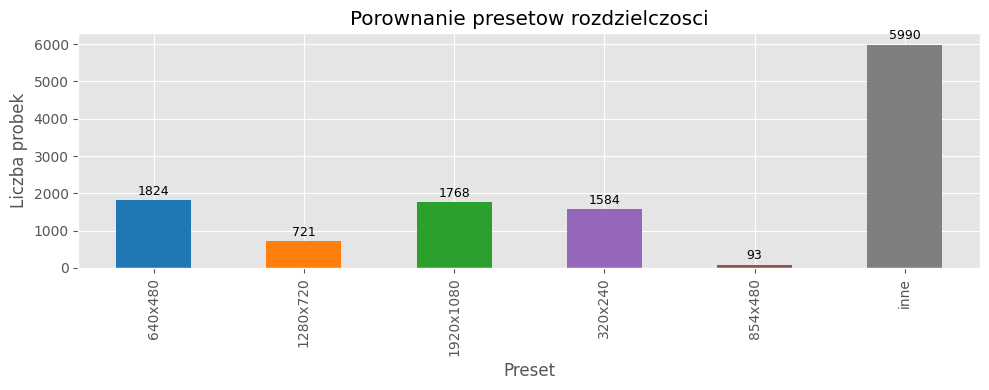

Top 15 rozdzielczosci:


,count
resolution,
288x192,2668
720x400,1875
640x480,1824
1920x1080,1768
320x240,1584
656x370,1045
1280x720,721
736x414,195
320x180,161


In [35]:
res_df = df.dropna(subset=['video_width', 'video_height']).copy()
res_df = res_df[(res_df['video_width'] > 0) & (res_df['video_height'] > 0)]
res_df['resolution'] = res_df['video_width'].astype(int).astype(str) + 'x' + res_df['video_height'].astype(int).astype(str)

preset_order = ['640x480', '1280x720', '1920x1080', '320x240', '854x480']
preset_counts = res_df['resolution'].value_counts()

preset_plot = pd.Series({preset: int(preset_counts.get(preset, 0)) for preset in preset_order})
other_count = int(len(res_df) - preset_plot.sum())
preset_plot['inne'] = other_count

fig, ax = plt.subplots(figsize=(10, 4))
preset_plot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#7f7f7f'])
ax.set_title('Porownanie presetow rozdzielczosci')
ax.set_xlabel('Preset')
ax.set_ylabel('Liczba probek')

for i, val in enumerate(preset_plot.values):
    ax.text(i, val + max(1, 0.01 * max(preset_plot.values)), str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('Top 15 rozdzielczosci:')
display(preset_counts.head(15).to_frame('count'))

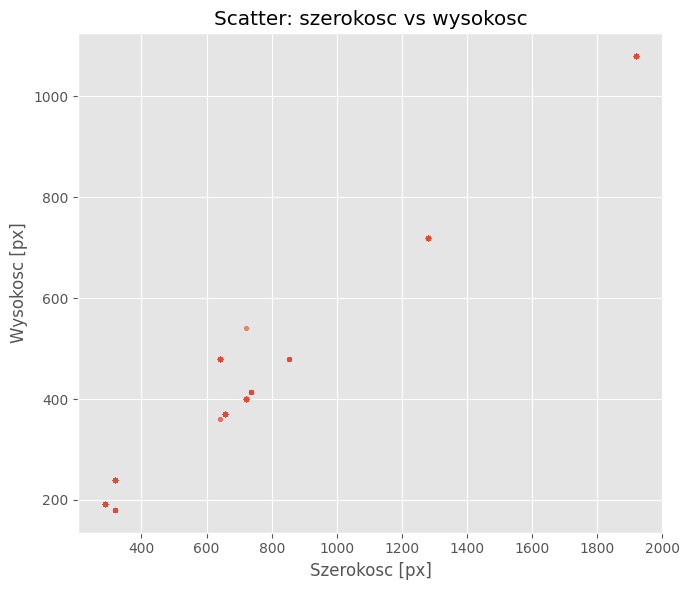

In [36]:
sample_scatter = df.dropna(subset=['video_width', 'video_height']).sample(min(3000, df.dropna(subset=['video_width', 'video_height']).shape[0]), random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample_scatter['video_width'], sample_scatter['video_height'], alpha=0.25, s=10)
ax.set_title('Scatter: szerokosc vs wysokosc')
ax.set_xlabel('Szerokosc [px]')
ax.set_ylabel('Wysokosc [px]')
plt.tight_layout()
plt.show()

## 7) Korelacje danych liczbowych + dodatkowe insighty

In [37]:
num_cols = ['start_frame', 'end_frame', 'length_frames', 'fps', 'signer_id', 'video_width', 'video_height', 'duration_sec']
num_df = df[num_cols].copy()

pearson_corr = num_df.corr(method='pearson')
spearman_corr = num_df.corr(method='spearman')

print('Pearson correlation matrix:')
display(pearson_corr.round(3))
print('Spearman correlation matrix:')
display(spearman_corr.round(3))

Pearson correlation matrix:


,start_frame,end_frame,length_frames,fps,signer_id,video_width,video_height,duration_sec
start_frame,1.000,-0.013,-0.014,0.006,-0.003,0.002,0.003,-0.015
end_frame,-0.013,1.000,1.000,0.235,0.044,-0.315,-0.280,0.952
length_frames,-0.014,1.000,1.000,0.235,0.044,-0.315,-0.280,0.952
fps,0.006,0.235,0.235,1.000,-0.249,-0.231,-0.214,-0.056
signer_id,-0.003,0.044,0.044,-0.249,1.000,0.084,0.060,0.105
video_width,0.002,-0.315,-0.315,-0.231,0.084,1.000,0.991,-0.294
video_height,0.003,-0.280,-0.280,-0.214,0.060,0.991,1.000,-0.266
duration_sec,-0.015,0.952,0.952,-0.056,0.105,-0.294,-0.266,1.000


Spearman correlation matrix:


,start_frame,end_frame,length_frames,fps,signer_id,video_width,video_height,duration_sec
start_frame,1.000,-0.013,-0.013,0.009,-0.006,0.005,0.005,-0.015
end_frame,-0.013,1.000,1.000,0.470,0.224,-0.007,0.018,0.961
length_frames,-0.013,1.000,1.000,0.470,0.224,-0.007,0.018,0.961
fps,0.009,0.470,0.470,1.000,0.076,0.112,0.195,0.268
signer_id,-0.006,0.224,0.224,0.076,1.000,0.322,0.272,0.244
video_width,0.005,-0.007,-0.007,0.112,0.322,1.000,0.889,0.018
video_height,0.005,0.018,0.018,0.195,0.272,0.889,1.000,0.016
duration_sec,-0.015,0.961,0.961,0.268,0.244,0.018,0.016,1.000


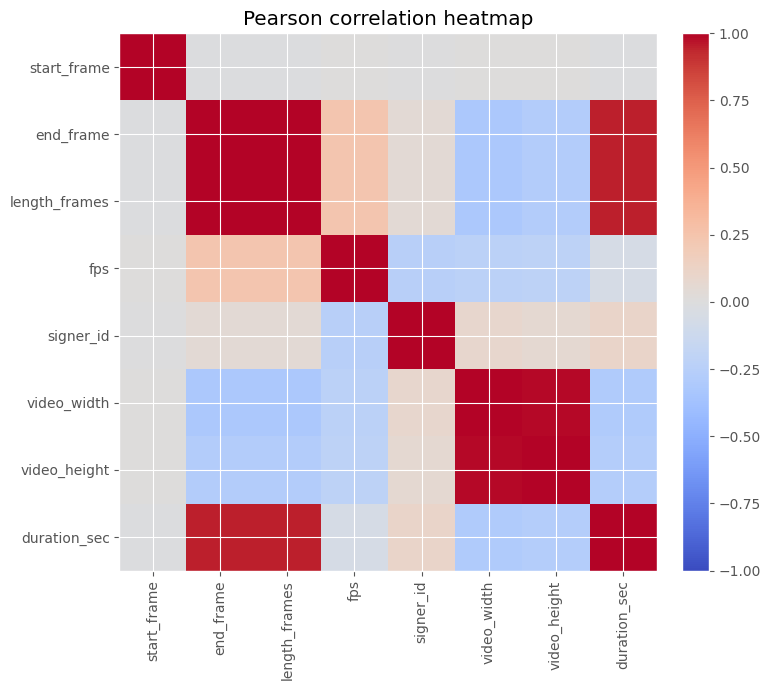

In [38]:
# Wizualizacja macierzy korelacji (Pearson)
corr = pearson_corr.fillna(0).values
labels = pearson_corr.columns.tolist()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)
ax.set_title('Pearson correlation heatmap')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

,samples
source,
signingsavvy,2668
signschool,1968
aslsearch,1875
asldeafined,1833
spreadthesign,1584
aslsignbank,1050
startasl,623
aslbrick,218
elementalasl,161


has_video,True
source,
aslbrick,100.0
asldeafined,100.0
aslsearch,100.0
aslsignbank,100.0
elementalasl,100.0
signingsavvy,100.0
signschool,100.0
spreadthesign,100.0
startasl,100.0


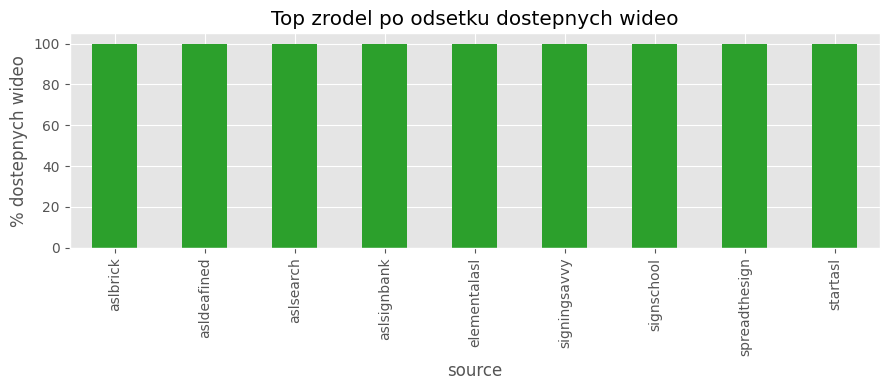

In [39]:
# Dodatkowy insight: czy posiadanie wideo zalezy od zrodla
source_avail = pd.crosstab(df['source'], df['has_video'], normalize='index') * 100
source_counts = df['source'].value_counts()

display(source_counts.to_frame('samples'))
display(source_avail.round(2))

if True in source_avail.columns:
    top_have = source_avail[True].sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(9, 4))
    top_have.plot(kind='bar', ax=ax, color='#2ca02c')
    ax.set_title('Top zrodel po odsetku dostepnych wideo')
    ax.set_ylabel('% dostepnych wideo')
    ax.set_xlabel('source')
    plt.tight_layout()
    plt.show()

## 8) Relacja: znak (label) vs dlugosc znaku

In [40]:
base_df = df_existing.copy() if 'df_existing' in globals() else df[df['has_video'] == True].copy()
label_duration_df = base_df.dropna(subset=['label', 'duration_sec']).copy()
label_length_df = base_df.dropna(subset=['label', 'length_frames']).copy()

label_duration_stats = label_duration_df.groupby('label').agg(
    samples=('duration_sec', 'size'),
    mean_duration=('duration_sec', 'mean'),
    median_duration=('duration_sec', 'median'),
    std_duration=('duration_sec', 'std'),
    q25_duration=('duration_sec', lambda s: s.quantile(0.25)),
    q75_duration=('duration_sec', lambda s: s.quantile(0.75)),
).sort_values('samples', ascending=False)

label_length_stats = label_length_df.groupby('label').agg(
    samples=('length_frames', 'size'),
    mean_frames=('length_frames', 'mean'),
    median_frames=('length_frames', 'median'),
    std_frames=('length_frames', 'std'),
).sort_values('samples', ascending=False)

print('Analiza tylko dla rekordow z dostepnym wideo (has_video=True)')
print('Top 20 klas: statystyki dlugosci [sekundy]')
display(label_duration_stats.head(20).round(3))

print('Top 20 klas: statystyki dlugosci [klatki]')
display(label_length_stats.head(20).round(2))

min_samples = 10
duration_corr_df = label_duration_stats[label_duration_stats['samples'] >= min_samples].copy()

if len(duration_corr_df) >= 3:
    rho, p_val = spearmanr(duration_corr_df['samples'], duration_corr_df['median_duration'])
    print(f"Spearman(samples, median_duration) dla klas z min {min_samples} probkami: rho={rho:.4f}, p-value={p_val:.4e}")
else:
    print('Za malo klas po filtracji, aby policzyc wiarygodna korelacje Spearmana.')

Analiza tylko dla rekordow z dostepnym wideo (has_video=True)
Top 20 klas: statystyki dlugosci [sekundy]


,samples,mean_duration,median_duration,std_duration,q25_duration,q75_duration
label,,,,,,
cool,16,2.032,2.188,0.684,1.673,2.460
before,16,2.112,1.806,0.857,1.574,2.875
thin,16,2.177,2.117,0.916,1.247,3.003
drink,15,2.269,2.002,0.824,1.714,2.819
go,15,2.004,2.035,0.708,1.551,2.151
who,14,2.389,2.169,1.057,1.666,2.732
cousin,14,2.675,2.486,0.839,2.319,3.184
help,14,2.106,2.200,0.445,1.860,2.461
computer,14,2.264,2.152,0.811,1.510,2.878


Top 20 klas: statystyki dlugosci [klatki]


,samples,mean_frames,median_frames,std_frames
label,,,,
cool,16,57.88,62.0,21.04
before,16,60.94,52.0,27.15
thin,16,62.31,58.0,27.65
drink,15,64.53,60.0,23.42
go,15,57.73,61.0,20.17
who,14,68.86,59.5,32.70
cousin,14,79.14,71.5,25.16
help,14,60.00,59.0,11.77
computer,14,67.93,64.5,24.45


Spearman(samples, median_duration) dla klas z min 10 probkami: rho=-0.0918, p-value=3.5392e-01


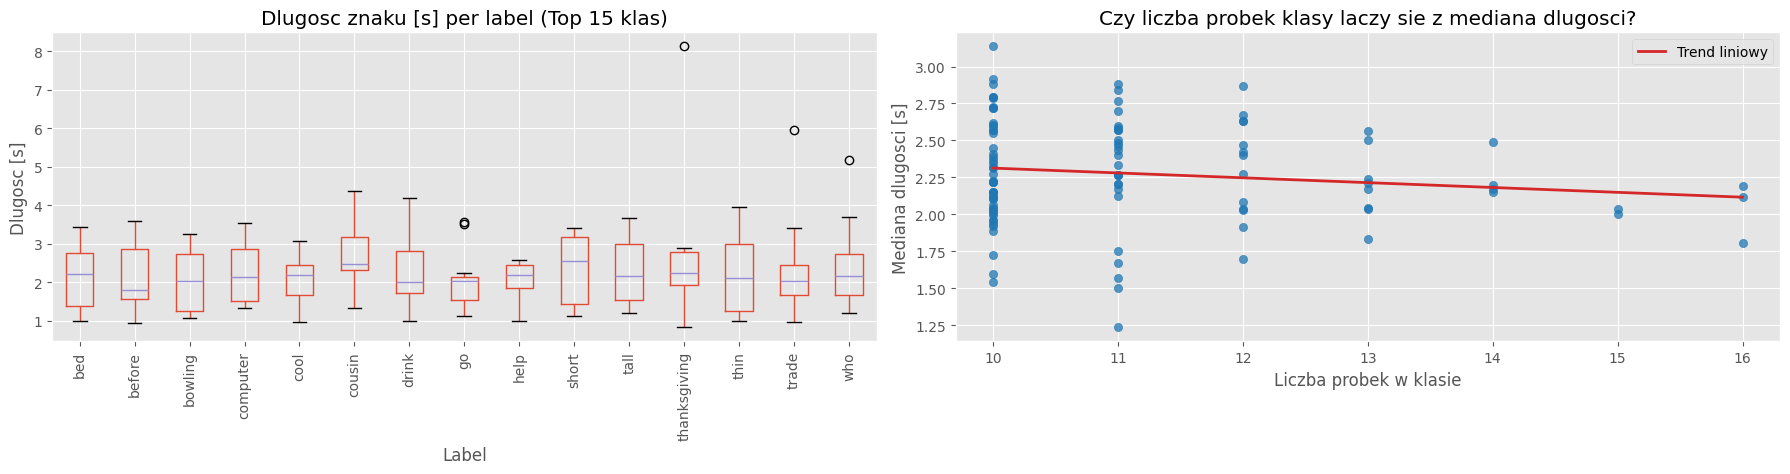

In [41]:
top_labels_by_samples = label_duration_stats.head(15).index
plot_df = label_duration_df[label_duration_df['label'].isin(top_labels_by_samples)].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plot_df.boxplot(column='duration_sec', by='label', ax=axes[0], rot=90)
axes[0].set_title('Dlugosc znaku [s] per label (Top 15 klas)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Dlugosc [s]')

axes[1].scatter(
    duration_corr_df['samples'],
    duration_corr_df['median_duration'],
    alpha=0.75,
    s=35,
    color='#1f77b4'
 )
axes[1].set_title('Czy liczba probek klasy laczy sie z mediana dlugosci?')
axes[1].set_xlabel('Liczba probek w klasie')
axes[1].set_ylabel('Mediana dlugosci [s]')

if len(duration_corr_df) >= 2:
    m, b = np.polyfit(duration_corr_df['samples'], duration_corr_df['median_duration'], 1)
    x = np.linspace(duration_corr_df['samples'].min(), duration_corr_df['samples'].max(), 100)
    axes[1].plot(x, m * x + b, color='#d62728', linewidth=2, label='Trend liniowy')
    axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

In [42]:
#SIGNER 19 = SUSSY